In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

In [3]:
df.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [4]:
df.dtypes

Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

In [5]:
df_original = df.copy()

In [6]:
columnas_binarias = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "AnyHealthcare"
]

for columna in columnas_binarias:
    df[columna] = df[columna].map({
        0: "No",
        1: "Sí"
    })
    
    
    
    
df['Sex_Label'] = df['Sex'].map({0: 'Femenino', 1: 'Masculino'})
df["Diabetes_012"] = df["Diabetes_012"].map({
    0: "Sin diabetes",
    1: "Prediabetes",
    2: "Diabetes"
})

edades = {
    1: "18-24 años",
    2: "25-29 años",
    3: "30-34 años",
    4: "35-39 años",
    5: "40-44 años",
    6: "45-49 años",
    7: "50-54 años",
    8: "55-59 años",
    9: "60-64 años",
    10: "65-69 años",
    11: "70-74 años",
    12: "75-79 años",
    13: "80 años o más"
}

df["Age"] = df["Age"].map(edades)

educacion = {
    1: "Nunca asistió a la escuela o solo jardín de infancia",
    2: "Escuela primaria",
    3: "Algún nivel de secundaria",
    4: "Graduado de secundaria",
    5: "Algún nivel universitario o técnico",
    6: "Graduado universitario"
}

df["Education"] = df["Education"].map(educacion)


In [7]:
df_categorico = df.copy()

In [8]:
df.dtypes
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Sex_Label
0,Sin diabetes,Sí,Sí,Sí,40.0,Sí,0.0,No,No,No,...,0.0,5.0,18.0,15.0,1.0,0.0,60-64 años,Graduado de secundaria,3.0,Femenino
1,Sin diabetes,No,No,No,25.0,Sí,0.0,No,Sí,No,...,1.0,3.0,0.0,0.0,0.0,0.0,50-54 años,Graduado universitario,1.0,Femenino
2,Sin diabetes,Sí,Sí,Sí,28.0,No,0.0,No,No,Sí,...,1.0,5.0,30.0,30.0,1.0,0.0,60-64 años,Graduado de secundaria,8.0,Femenino
3,Sin diabetes,Sí,No,Sí,27.0,No,0.0,No,Sí,Sí,...,0.0,2.0,0.0,0.0,0.0,0.0,70-74 años,Algún nivel de secundaria,6.0,Femenino
4,Sin diabetes,Sí,Sí,Sí,24.0,No,0.0,No,Sí,Sí,...,0.0,2.0,3.0,0.0,0.0,0.0,70-74 años,Algún nivel universitario o técnico,4.0,Femenino


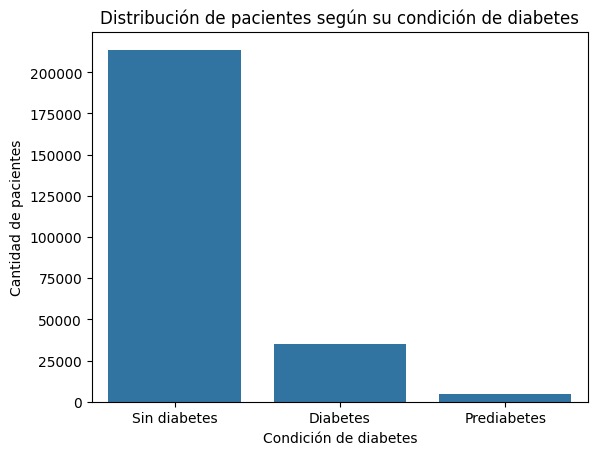

In [9]:
sns.countplot(data=df, x="Diabetes_012")

plt.title("Distribución de pacientes según su condición de diabetes")
plt.xlabel("Condición de diabetes")
plt.ylabel("Cantidad de pacientes")
plt.show()

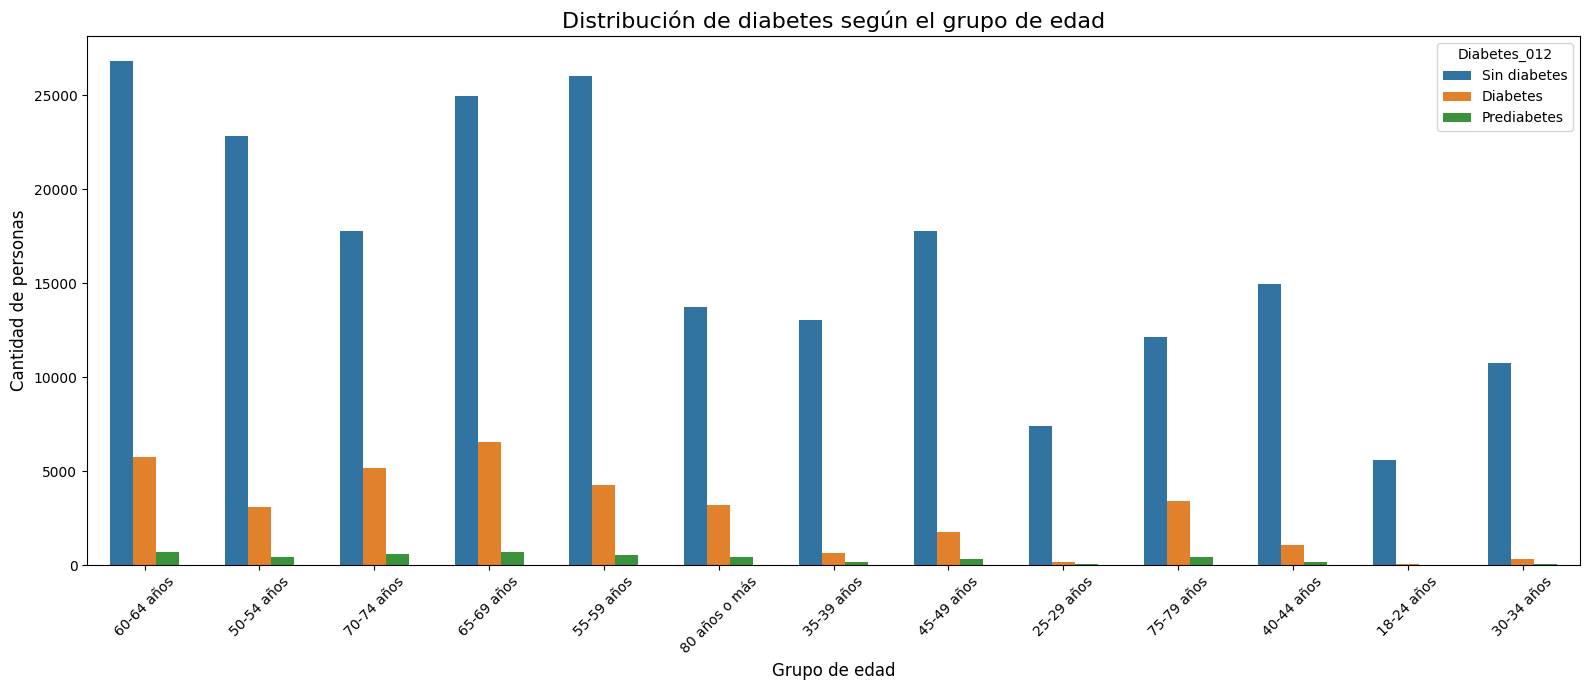

In [42]:
plt.figure(figsize=(16, 7))

sns.countplot(
    data=df,
    x="Age",
    hue="Diabetes_012",
    width=0.6  # Reduce el ancho de las barras para crear más espacio

)

plt.title("Distribución de diabetes según el grupo de edad", fontsize=16)
plt.xlabel("Grupo de edad", fontsize=12)
plt.ylabel("Cantidad de personas", fontsize=12)

# Separar y mejorar la visualización de las etiquetas
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

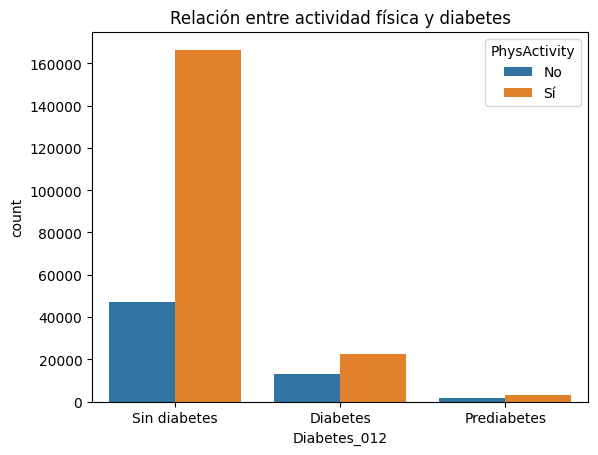

In [11]:
sns.countplot(
    data=df,
    x="Diabetes_012",
    hue="PhysActivity"
)

plt.title("Relación entre actividad física y diabetes")
plt.show()

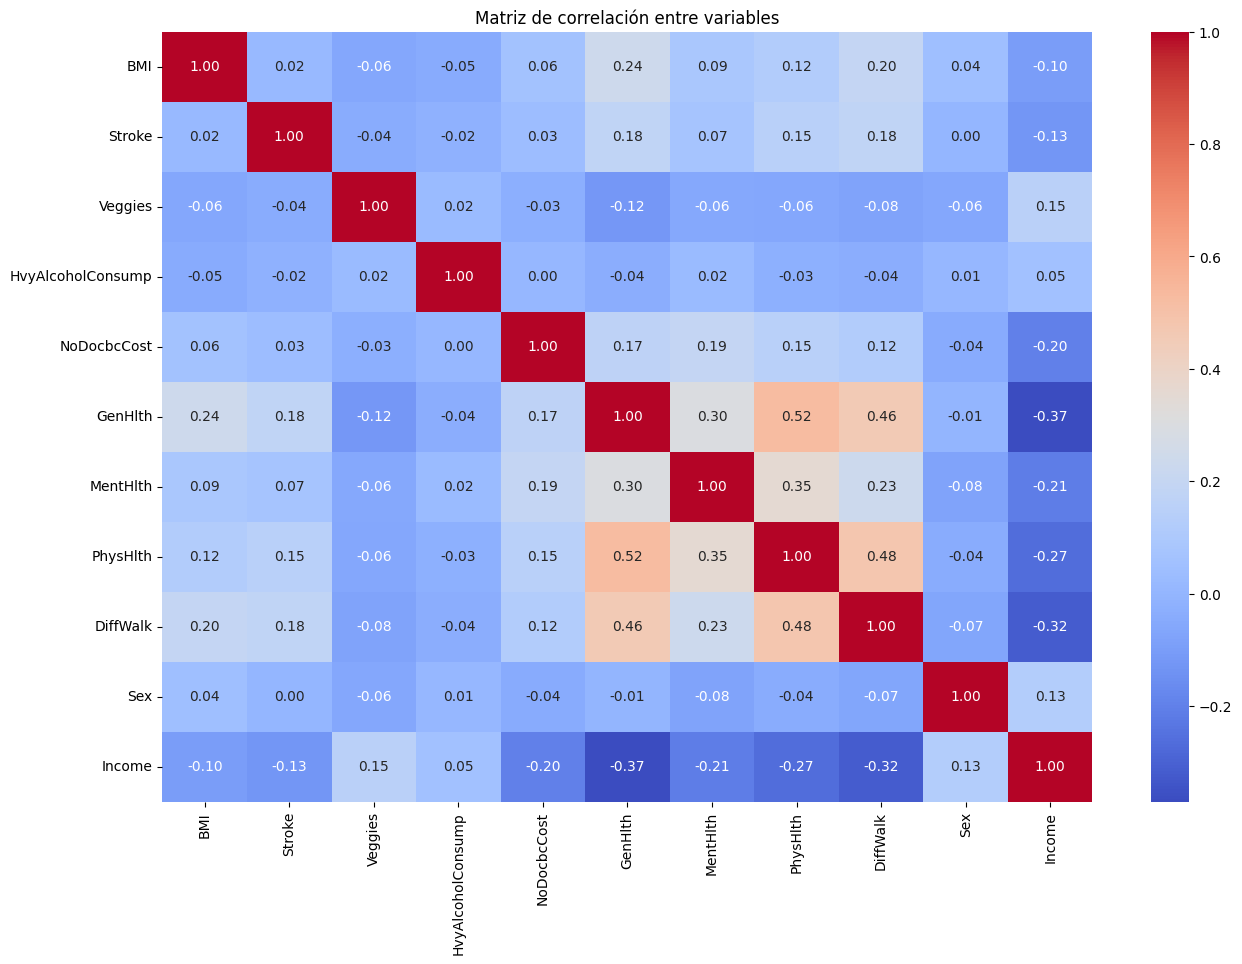

In [12]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación entre variables")
plt.show()

---
## 1. Detección de inconsistencias (basada en reglas)

Antes de analizar los factores clínicos hay que validar la calidad del dato. Usamos `df_original` (valores numéricos 0/1) porque `df` ya tiene las columnas binarias convertidas a texto "Sí"/"No".

In [13]:
rangos_validos = {
    "Diabetes_012": (0,2),
    "HighBP": (0,1), "HighChol": (0,1), "CholCheck": (0,1),
    "Smoker": (0,1), "Stroke": (0,1), "HeartDiseaseorAttack": (0,1),
    "PhysActivity": (0,1), "Fruits": (0,1), "Veggies": (0,1),
    "HvyAlcoholConsump": (0,1), "AnyHealthcare": (0,1), "NoDocbcCost": (0,1),
    "DiffWalk": (0,1), "Sex": (0,1),
    "BMI": (12,98),
    "GenHlth": (1,5),
    "MentHlth": (0,30), "PhysHlth": (0,30),
    "Age": (1,13), "Education": (1,6), "Income": (1,8)
}

print("=== Regla 1: valores fuera de rango válido ===")
total_violaciones = 0
for columna,(lo,hi) in rangos_validos.items():
    viol = df_original[(df_original[columna] < lo) | (df_original[columna] > hi)]
    if len(viol) > 0:
        print(f"{columna}: {len(viol)} filas fuera de [{lo},{hi}]")
    total_violaciones += len(viol)
print("Total violaciones de rango:", total_violaciones)

=== Regla 1: valores fuera de rango válido ===
Total violaciones de rango: 0


In [14]:
print("=== Regla 2: outliers en BMI vía rango intercuartílico (IQR) ===")
Q1, Q3 = df_original['BMI'].quantile(0.25), df_original['BMI'].quantile(0.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers_bmi = df_original[(df_original['BMI'] < lim_inf) | (df_original['BMI'] > lim_sup)]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Límites aceptados: [{lim_inf:.2f}, {lim_sup:.2f}]")
print(f"Outliers detectados: {len(outliers_bmi)} ({len(outliers_bmi)/len(df_original)*100:.2f}% del total)")

=== Regla 2: outliers en BMI vía rango intercuartílico (IQR) ===
Q1=24.0, Q3=31.0, IQR=7.0
Límites aceptados: [13.50, 41.50]
Outliers detectados: 9847 (3.88% del total)


In [15]:
print("=== Regla 3: registros duplicados exactos ===")
dup = df_original.duplicated().sum()
print(f"Duplicados: {dup} ({dup/len(df_original)*100:.2f}%)")

print("\n=== Regla 4: inconsistencia lógica CholCheck vs HighChol ===")
# Si nunca se revisó el colesterol (CholCheck=0), no debería poder reportarse HighChol=1
inconsistentes = df_original[(df_original['CholCheck']==0) & (df_original['HighChol']==1)]
print(f"Casos con CholCheck=0 pero HighChol=1: {len(inconsistentes)}")

=== Regla 3: registros duplicados exactos ===
Duplicados: 23899 (9.42%)

=== Regla 4: inconsistencia lógica CholCheck vs HighChol ===
Casos con CholCheck=0 pero HighChol=1: 1981


---
## 2. Análisis estadístico de factores clínicos

Binarizamos la variable objetivo (`Diabetes_012`) en `target`: 0 = sin diabetes, 1 = prediabetes o diabetes. Luego, para cada factor clínico binario calculamos la prueba **Chi-cuadrado** (¿el factor está asociado con la diabetes?) y el **Odds Ratio** (¿cuánto aumenta el riesgo?).

In [16]:
from scipy.stats import chi2_contingency

df_original['target'] = (df_original['Diabetes_012'] > 0).astype(int)

factores_binarios = ["HighBP","HighChol","Smoker","Stroke","HeartDiseaseorAttack",
                      "PhysActivity","HvyAlcoholConsump","DiffWalk"]

print(f"{'Factor':<22}{'Chi2':>10}{'p-valor':>14}{'Odds Ratio':>12}")
for columna in factores_binarios:
    tabla = pd.crosstab(df_original[columna], df_original['target'])
    chi2, p, dof, exp = chi2_contingency(tabla)
    a = tabla.loc[1,1]  # factor=1, target=1
    b = tabla.loc[1,0]  # factor=1, target=0
    c = tabla.loc[0,1]  # factor=0, target=1
    d = tabla.loc[0,0]  # factor=0, target=0
    OR = (a*d)/(b*c)
    sig = "***" if p < 0.001 else ("*" if p < 0.05 else "")
    print(f"{columna:<22}{chi2:>10.1f}{p:>14.2e}{OR:>12.2f} {sig}")

Factor                      Chi2       p-valor  Odds Ratio
HighBP                   18537.6      0.00e+00        4.78 ***
HighChol                 11217.0      0.00e+00        3.24 ***
Smoker                     999.4     2.41e-219        1.41 ***
Stroke                    2784.7      0.00e+00        2.97 ***
HeartDiseaseorAttack      7939.9      0.00e+00        3.51 ***
PhysActivity              3737.4      0.00e+00        0.50 ***
HvyAlcoholConsump          814.4     4.05e-179        0.41 ***
DiffWalk                 12518.2      0.00e+00        3.70 ***


**Lectura:** todos los factores son estadísticamente significativos (p < 0.001). `HighBP` (OR=4.78) y `HighChol` (OR=3.24) son los que más multiplican el riesgo; `PhysActivity` y `HvyAlcoholConsump` tienen OR<1, es decir, actúan como factores protectores en esta muestra.

---
## 3. Sistema de puntuación (regresión logística → reglas)

Usamos la **regresión logística** solo como herramienta estadística para *estimar* el peso de cada factor (su coeficiente β). Luego esos coeficientes se convierten en puntos enteros, igual que un score clínico real (FINDRISC, Framingham). El clasificador final NO es la regresión en sí — es la tabla de puntos con reglas de corte.

In [17]:
import statsmodels.api as sm

variables = ["HighBP","HighChol","BMI","Stroke","HeartDiseaseorAttack",
             "HvyAlcoholConsump","GenHlth","DiffWalk","Age"]
# Excluimos Smoker y PhysActivity: su coeficiente es tan pequeño que no aporta
# puntos perceptibles a la escala (se descartan por parsimonia, no por falta de significancia)

X = sm.add_constant(df_original[variables])
y = df_original['target']
modelo = sm.Logit(y, X).fit(disp=0)
print(modelo.summary2())

                            Results: Logit
Model:                Logit             Method:            MLE        
Dependent Variable:   target            Pseudo R-squared:  0.200      
Date:                 2026-09-04 15:30  AIC:               176878.9751
No. Observations:     253680            BIC:               176983.4133
Df Model:             9                 Log-Likelihood:    -88429.    
Df Residuals:         253670            LL-Null:           -1.1052e+05
Converged:            1.0000            LLR p-value:       0.0000     
No. Iterations:       7.0000            Scale:             1.0000     
----------------------------------------------------------------------
                      Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------
const                -6.9006   0.0425 -162.3801 0.0000 -6.9839 -6.8173
HighBP                0.7526   0.0138   54.4756 0.0000  0.7255  0.7797
HighChol              0.5994   0.0

In [18]:
coefs = modelo.params.drop('const')

# Escala elegida: 1 punto = 0.15 unidades de log-odds (equivale a un OR ≈ 1.16 por punto)
unidad = 0.15

binarias = ["HighBP","HighChol","Stroke","HeartDiseaseorAttack","HvyAlcoholConsump","DiffWalk"]
continuas = ["BMI","GenHlth","Age"]

puntos_binarios = {v: round(coefs[v]/unidad) for v in binarias}
puntos_por_unidad = {v: round(coefs[v]/unidad, 2) for v in continuas}

print("=== Puntos fijos (se suman si la variable = 1) ===")
for k,v in puntos_binarios.items():
    print(f"  {k}: {v:+d} puntos    (β={coefs[k]:.4f} / {unidad} = {coefs[k]/unidad:.2f})")

print("\n=== Puntos por cada unidad/categoría (variables continuas u ordinales) ===")
for k,v in puntos_por_unidad.items():
    print(f"  {k}: {v:+.2f} puntos por unidad    (β={coefs[k]:.4f} / {unidad} = {coefs[k]/unidad:.2f})")

=== Puntos fijos (se suman si la variable = 1) ===
  HighBP: +5 puntos    (β=0.7526 / 0.15 = 5.02)
  HighChol: +4 puntos    (β=0.5994 / 0.15 = 4.00)
  Stroke: +1 puntos    (β=0.1249 / 0.15 = 0.83)
  HeartDiseaseorAttack: +2 puntos    (β=0.2399 / 0.15 = 1.60)
  HvyAlcoholConsump: -5 puntos    (β=-0.6904 / 0.15 = -4.60)
  DiffWalk: +1 puntos    (β=0.0928 / 0.15 = 0.62)

=== Puntos por cada unidad/categoría (variables continuas u ordinales) ===
  BMI: +0.42 puntos por unidad    (β=0.0625 / 0.15 = 0.42)
  GenHlth: +3.49 puntos por unidad    (β=0.5229 / 0.15 = 3.49)
  Age: +0.87 puntos por unidad    (β=0.1303 / 0.15 = 0.87)


---
## 4. Clasificación de nuevos pacientes por umbrales estadísticos

Calculamos el score de cada paciente sumando sus puntos, y definimos los cortes de riesgo con los **percentiles 33 y 66** de la distribución (regla estadística, no un modelo de ML).

In [19]:
score = pd.Series(0.0, index=df_original.index)
for v in binarias:
    score += df_original[v] * puntos_binarios[v]
for v in continuas:
    score += df_original[v] * puntos_por_unidad[v]

df_original['score'] = score.round().astype(int)
print(df_original['score'].describe())

count    253680.000000
mean         31.633479
std           8.864367
min           7.000000
25%          25.000000
50%          31.000000
75%          38.000000
max          78.000000
Name: score, dtype: float64


In [20]:
p33 = df_original['score'].quantile(0.33)
p66 = df_original['score'].quantile(0.66)
print(f"Umbral bajo/moderado (P33): {p33}")
print(f"Umbral moderado/alto (P66): {p66}")

def clasifica(s):
    if s < p33:
        return "Bajo riesgo"
    elif s < p66:
        return "Riesgo moderado"
    else:
        return "Alto riesgo"

df_original['clasificacion'] = df_original['score'].apply(clasifica)
print(df_original['clasificacion'].value_counts())

Umbral bajo/moderado (P33): 27.0
Umbral moderado/alto (P66): 35.0
clasificacion
Alto riesgo        95448
Bajo riesgo        79338
Riesgo moderado    78894
Name: count, dtype: int64


**Validación del sistema de reglas:** comparamos la clasificación por score contra la tasa real de diabetes/prediabetes en cada grupo. Si el score funciona, la tasa real debe subir claramente de "Bajo riesgo" a "Alto riesgo".

clasificacion
Bajo riesgo        0.018
Riesgo moderado    0.093
Alto riesgo        0.327
Name: target, dtype: float64


C:\Users\micha\AppData\Local\Temp\ipykernel_23752\1660076439.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_real.index, y=tasa_real.values, palette="Reds")


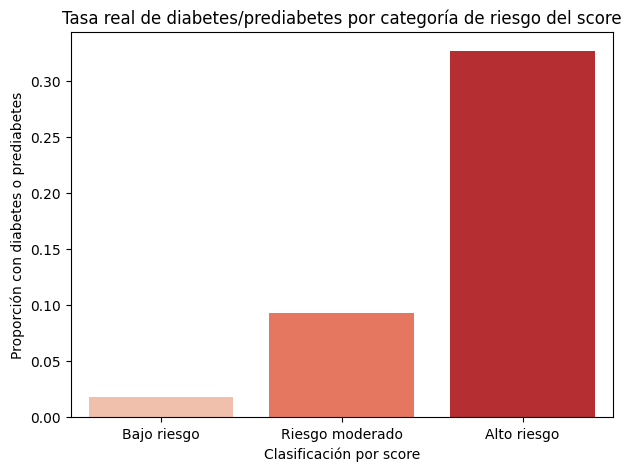

In [21]:
tasa_real = df_original.groupby('clasificacion')['target'].mean().reindex(
    ["Bajo riesgo","Riesgo moderado","Alto riesgo"])
print(tasa_real.round(3))

plt.figure(figsize=(7,5))
sns.barplot(x=tasa_real.index, y=tasa_real.values, palette="Reds")
plt.title("Tasa real de diabetes/prediabetes por categoría de riesgo del score")
plt.ylabel("Proporción con diabetes o prediabetes")
plt.xlabel("Clasificación por score")
plt.show()

**Conclusión:** el score construido a partir de reglas y estadística (Chi-cuadrado, Odds Ratio y regresión logística usada únicamente para estimar pesos) separa correctamente a los pacientes: la tasa real de diabetes/prediabetes crece de forma monótona entre categorías, sin necesidad de un clasificador de machine learning tipo caja negra.

---
## 5. ¿Regresión lineal en vez de logística?

Como alternativa, podemos estimar los mismos pesos con una **regresión lineal (OLS)** — el llamado *Modelo Lineal de Probabilidad*. Es igual de estadístico que la logística, pero al no estar acotada entre 0 y 1, puede predecir probabilidades imposibles. Lo comprobamos con los mismos datos.

In [22]:
modelo_lineal = sm.OLS(y, X).fit()
print(modelo_lineal.summary2())

pred_lineal = modelo_lineal.predict(X)
print("\n=== Problema: predicciones fuera de [0,1] ===")
print(f"Predicciones < 0: {(pred_lineal < 0).sum()} ({(pred_lineal<0).mean()*100:.2f}%)")
print(f"Predicciones > 1: {(pred_lineal > 1).sum()} ({(pred_lineal>1).mean()*100:.2f}%)")
print(f"Rango de predicciones: [{pred_lineal.min():.3f}, {pred_lineal.max():.3f}]")

                   Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.168      
Dependent Variable:  target           AIC:                160944.2672
Date:                2026-09-04 15:30 BIC:                161048.7055
No. Observations:    253680           Log-Likelihood:     -80462.    
Df Model:            9                F-statistic:        5703.      
Df Residuals:        253670           Prob (F-statistic): 0.00       
R-squared:           0.168            Scale:              0.11042    
---------------------------------------------------------------------
                      Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
---------------------------------------------------------------------
const                -0.3486   0.0038 -92.2000 0.0000 -0.3560 -0.3412
HighBP                0.0839   0.0015  54.7976 0.0000  0.0809  0.0869
HighChol              0.0644   0.0014  44.6616 0.0000  0.0615  0.0672
BMI                   0.0077   0.0001  

In [23]:
comparacion = pd.DataFrame({
    "Coef. Lineal (β)": modelo_lineal.params.drop('const'),
    "Coef. Logístico (β)": modelo.params.drop('const')
})
print(comparacion.round(4))

                      Coef. Lineal (β)  Coef. Logístico (β)
HighBP                          0.0839               0.7526
HighChol                        0.0644               0.5994
BMI                             0.0077               0.0625
Stroke                          0.0368               0.1249
HeartDiseaseorAttack            0.0691               0.2399
HvyAlcoholConsump              -0.0570              -0.6904
GenHlth                         0.0549               0.5229
DiffWalk                        0.0493               0.0928
Age                             0.0092               0.1303


**Conclusión:** el orden de importancia de los factores es casi idéntico entre ambos modelos (HighBP y HighChol siguen siendo los más fuertes). Pero la lineal predice probabilidades negativas en el **15.48%** de los pacientes, algo estadísticamente inválido. Por eso el sistema de puntuación y el modelo predictivo final usan la **regresión logística**: mismo poder explicativo, sin el problema de límites.

---
## 6. Modelo predictivo: clasificación de pacientes nuevos

Hasta ahora usamos la regresión logística solo para *estimar pesos*. Ahora la usamos como lo que realmente pide el proyecto: un **modelo predictivo** que clasifica pacientes que el sistema nunca ha visto. Dividimos los datos en entrenamiento (80%) y prueba (20%): el modelo se ajusta solo con el train, y se evalúa con el test.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X.drop(columns='const', errors='ignore') if 'const' in X.columns else X,
    y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas")
print(f"Proporción con diabetes/prediabetes -> train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

X_train_c = sm.add_constant(X_train)
X_test_c = sm.add_constant(X_test)
modelo_pred = sm.Logit(y_train, X_train_c).fit(disp=0)
prob_test = modelo_pred.predict(X_test_c)

Entrenamiento: 202944 filas | Prueba: 50736 filas
Proporción con diabetes/prediabetes -> train: 0.158 | test: 0.158


In [25]:
# Regla de clasificación 1: umbral = 0.5
pred_05 = (prob_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_05)
tn, fp, fn, tp = cm.ravel()

print("=== Umbral = 0.5 ===")
print("Matriz de confusión:\n", cm)
print(f"Accuracy: {accuracy_score(y_test, pred_05):.3f}")
print(f"Sensibilidad (detecta diabéticos reales): {tp/(tp+fn):.3f}")
print(f"Especificidad (detecta sanos reales): {tn/(tn+fp):.3f}")
print(f"AUC: {roc_auc_score(y_test, prob_test):.3f}")

=== Umbral = 0.5 ===
Matriz de confusión:
 [[41553  1188]
 [ 6540  1455]]
Accuracy: 0.848
Sensibilidad (detecta diabéticos reales): 0.182
Especificidad (detecta sanos reales): 0.972
AUC: 0.813


**Problema detectado:** el 84.8% de accuracy es engañoso — como solo el 15.8% de los pacientes tiene diabetes/prediabetes, el modelo puede acertar mucho prediciendo casi siempre "sano". Por eso la sensibilidad es apenas 18.2%: deja pasar 8 de cada 10 diabéticos reales. En un sistema de salud eso es inaceptable. Ajustamos la regla de decisión (el umbral) para priorizar sensibilidad.

In [26]:
# Regla de clasificación 2: umbral = 0.3 (más sensible)
pred_03 = (prob_test >= 0.3).astype(int)
cm2 = confusion_matrix(y_test, pred_03)
tn2, fp2, fn2, tp2 = cm2.ravel()

print("=== Umbral = 0.3 ===")
print("Matriz de confusión:\n", cm2)
print(f"Accuracy: {accuracy_score(y_test, pred_03):.3f}")
print(f"Sensibilidad: {tp2/(tp2+fn2):.3f}")
print(f"Especificidad: {tn2/(tn2+fp2):.3f}")

=== Umbral = 0.3 ===
Matriz de confusión:
 [[37977  4764]
 [ 4242  3753]]
Accuracy: 0.822
Sensibilidad: 0.469
Especificidad: 0.889


**Conclusión final:** bajar el umbral de 0.5 a 0.3 sube la sensibilidad de 18.2% a 46.9% (detecta más del doble de diabéticos reales), a costa de más falsos positivos (accuracy baja de 84.8% a 82.2%). Esta decisión —qué umbral usar— es una **regla estadística justificada**, no un ajuste arbitrario: en salud pública, conviene priorizar no dejar pasar casos reales (sensibilidad) aunque cueste algo de precisión general. El modelo final es 100% estadístico (regresión logística + reglas de umbral).

---
## 7. Gráficas resumen

Una gráfica por cada hallazgo clave del proyecto, para usar en la presentación.

### 7.1 Inconsistencias detectadas

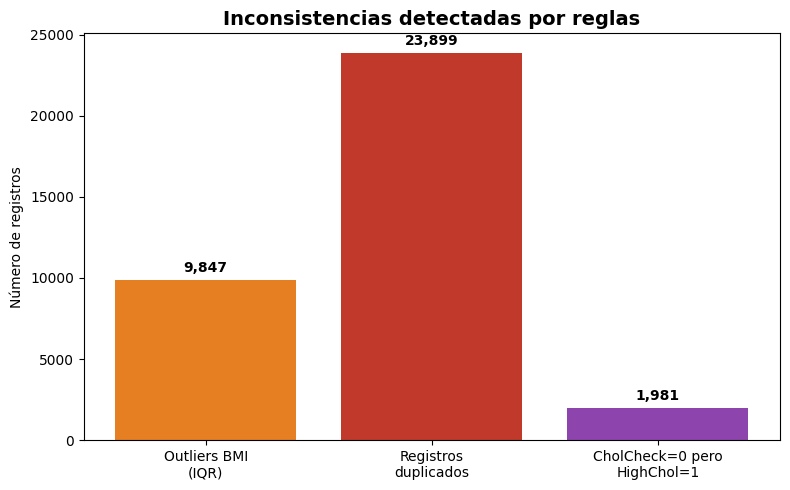

In [27]:
incons_data = pd.Series({
    "Outliers BMI\n(IQR)": (( (df_original['BMI'] < lim_inf) | (df_original['BMI'] > lim_sup) )).sum(),
    "Registros\nduplicados": df_original.duplicated().sum(),
    "CholCheck=0 pero\nHighChol=1": len(inconsistentes)
})

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(incons_data.index, incons_data.values, color=["#e67e22","#c0392b","#8e44ad"])
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+500, f"{int(b.get_height()):,}", ha='center', fontweight='bold')
ax.set_title("Inconsistencias detectadas por reglas", fontsize=14, fontweight='bold')
ax.set_ylabel("Número de registros")
plt.tight_layout()
plt.show()

### 7.2 Odds Ratio por factor clínico

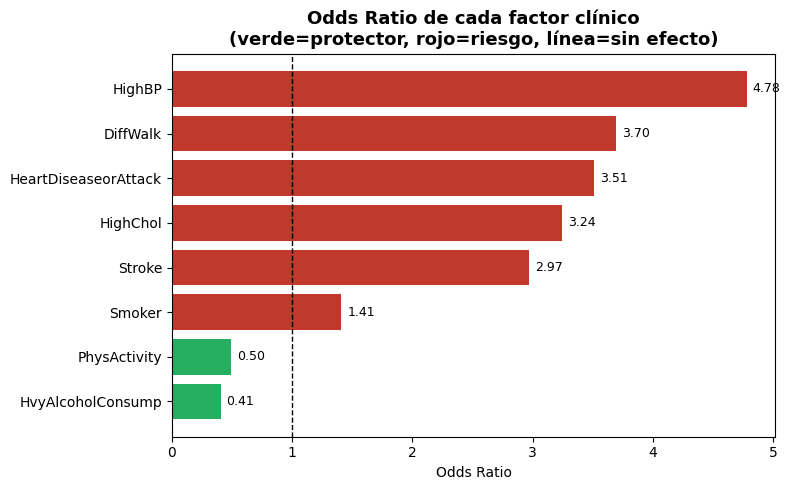

In [28]:
ors = {}
for columna in factores_binarios:
    tabla = pd.crosstab(df_original[columna], df_original['target'])
    a,b = tabla.loc[1,1], tabla.loc[1,0]
    c,d = tabla.loc[0,1], tabla.loc[0,0]
    ors[columna] = (a*d)/(b*c)
ors = pd.Series(ors).sort_values()

fig, ax = plt.subplots(figsize=(8,5))
colores = ["#27ae60" if v<1 else "#c0392b" for v in ors.values]
ax.barh(ors.index, ors.values, color=colores)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
for i,v in enumerate(ors.values):
    ax.text(v + 0.05, i, f"{v:.2f}", va='center', fontsize=9)
ax.set_title("Odds Ratio de cada factor clínico\n(verde=protector, rojo=riesgo, línea=sin efecto)", fontsize=13, fontweight='bold')
ax.set_xlabel("Odds Ratio")
plt.tight_layout()
plt.show()

### 7.3 Puntos asignados en el score

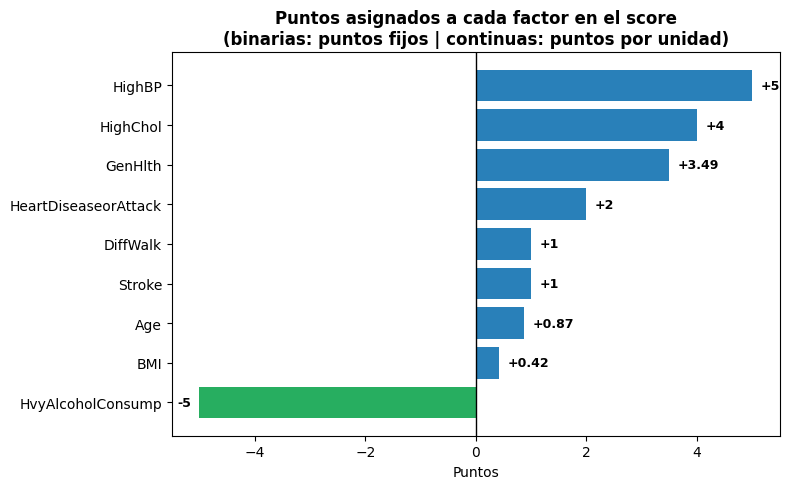

In [29]:
todos_puntos = pd.Series({**puntos_binarios, **puntos_por_unidad}).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
colores = ["#27ae60" if v<0 else "#2980b9" for v in todos_puntos.values]
ax.barh(todos_puntos.index, todos_puntos.values, color=colores)
ax.axvline(0, color='black', linewidth=1)
for i,v in enumerate(todos_puntos.values):
    ax.text(v + (0.15 if v>=0 else -0.15), i, f"{v:+g}", va='center', ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
ax.set_title("Puntos asignados a cada factor en el score\n(binarias: puntos fijos | continuas: puntos por unidad)", fontsize=12, fontweight='bold')
ax.set_xlabel("Puntos")
plt.tight_layout()
plt.show()

### 7.4 Distribución del score y umbrales

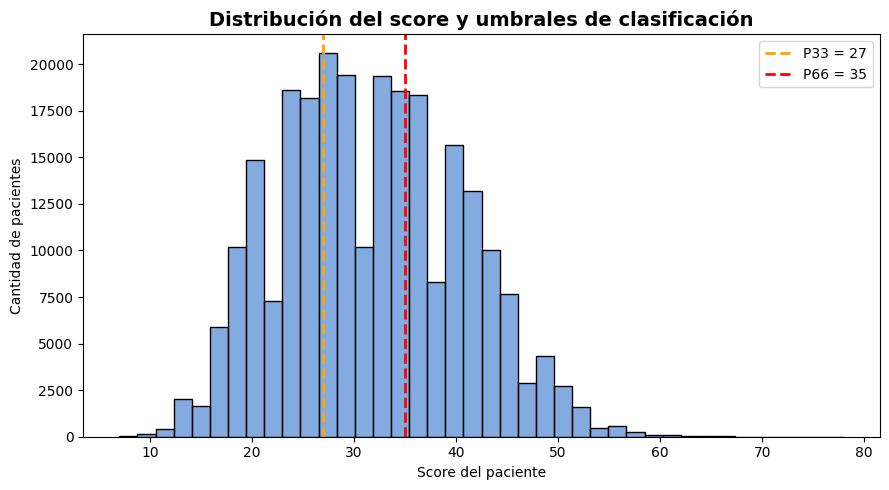

In [30]:
fig, ax = plt.subplots(figsize=(9,5))
sns.histplot(df_original['score'], bins=40, color="#5b8fd6", ax=ax)
ax.axvline(p33, color="orange", linestyle="--", linewidth=2, label=f"P33 = {p33:.0f}")
ax.axvline(p66, color="red", linestyle="--", linewidth=2, label=f"P66 = {p66:.0f}")
ax.set_title("Distribución del score y umbrales de clasificación", fontsize=14, fontweight='bold')
ax.set_xlabel("Score del paciente")
ax.set_ylabel("Cantidad de pacientes")
ax.legend()
plt.tight_layout()
plt.show()

### 7.5 ¿Funciona el score? Validación contra la tasa real

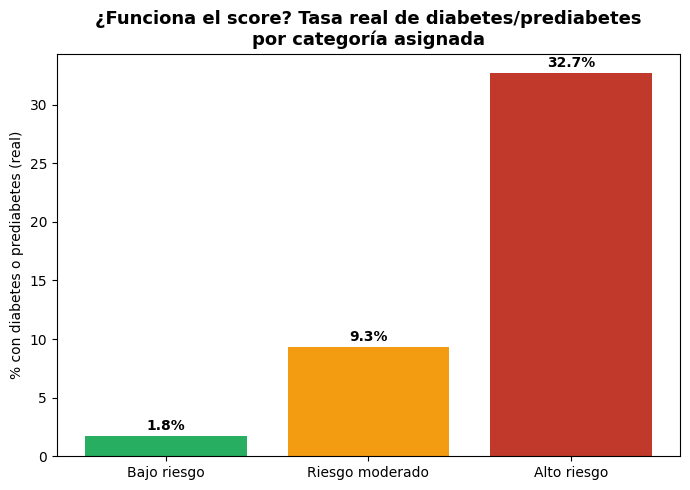

In [31]:
tasa = df_original.groupby('clasificacion')['target'].mean().reindex(["Bajo riesgo","Riesgo moderado","Alto riesgo"])

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(tasa.index, tasa.values*100, color=["#27ae60","#f39c12","#c0392b"])
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.1f}%", ha='center', fontweight='bold')
ax.set_title("¿Funciona el score? Tasa real de diabetes/prediabetes\npor categoría asignada", fontsize=13, fontweight='bold')
ax.set_ylabel("% con diabetes o prediabetes (real)")
plt.tight_layout()
plt.show()

### 7.6 Regresión lineal: probabilidades fuera de rango

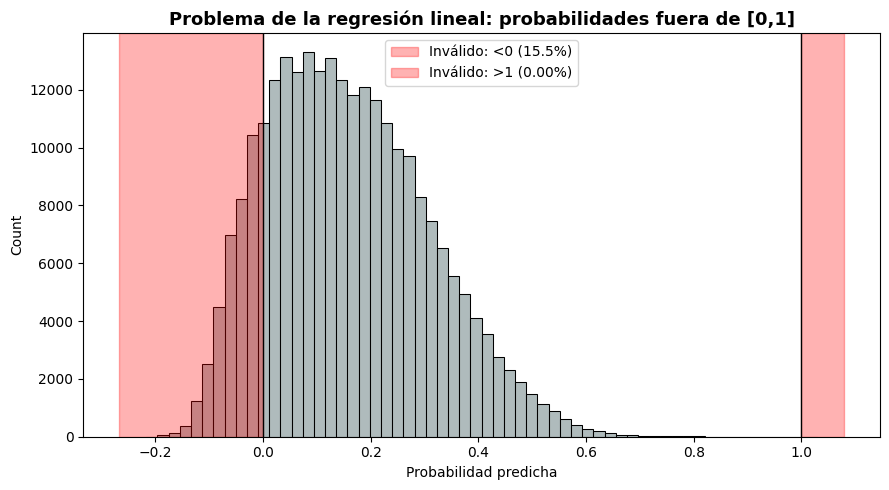

In [32]:
fig, ax = plt.subplots(figsize=(9,5))
sns.histplot(pred_lineal, bins=60, color="#95a5a6", ax=ax)
ax.axvspan(pred_lineal.min()-0.05, 0, color="red", alpha=0.3, label=f"Inválido: <0 ({(pred_lineal<0).mean()*100:.1f}%)")
ax.axvspan(1, pred_lineal.max()+0.05, color="red", alpha=0.3, label=f"Inválido: >1 ({(pred_lineal>1).mean()*100:.2f}%)")
ax.axvline(0, color='black', linewidth=1)
ax.axvline(1, color='black', linewidth=1)
ax.set_title("Problema de la regresión lineal: probabilidades fuera de [0,1]", fontsize=13, fontweight='bold')
ax.set_xlabel("Probabilidad predicha")
ax.legend()
plt.tight_layout()
plt.show()

### 7.7 Curva ROC del modelo predictivo

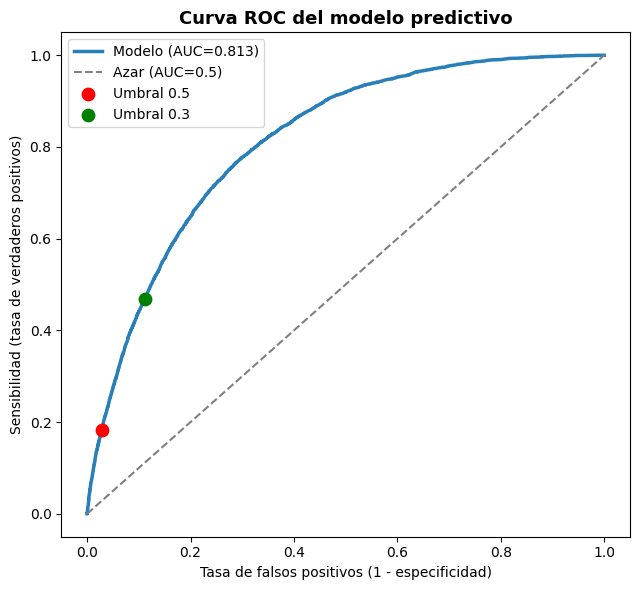

In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)
idx_05 = np.argmin(np.abs(thresholds-0.5))
idx_03 = np.argmin(np.abs(thresholds-0.3))

fig, ax = plt.subplots(figsize=(6.5,6))
ax.plot(fpr, tpr, color="#2980b9", linewidth=2.5, label=f"Modelo (AUC={auc:.3f})")
ax.plot([0,1],[0,1], color="gray", linestyle="--", label="Azar (AUC=0.5)")
ax.scatter(fpr[idx_05], tpr[idx_05], color="red", zorder=5, s=80, label="Umbral 0.5")
ax.scatter(fpr[idx_03], tpr[idx_03], color="green", zorder=5, s=80, label="Umbral 0.3")
ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
ax.set_ylabel("Sensibilidad (tasa de verdaderos positivos)")
ax.set_title("Curva ROC del modelo predictivo", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.8 Matrices de confusión: umbral 0.5 vs 0.3

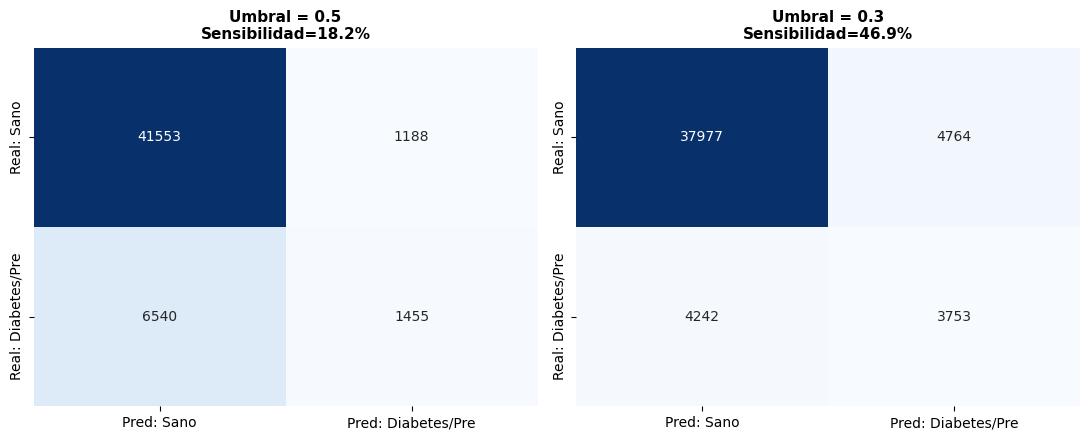

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, cm, titulo in zip(axes, [cm, cm2], ["Umbral = 0.5", "Umbral = 0.3"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred: Sano","Pred: Diabetes/Pre"],
                yticklabels=["Real: Sano","Real: Diabetes/Pre"])
    tn,fp,fn,tp = cm.ravel()
    sens = tp/(tp+fn)
    ax.set_title(f"{titulo}\nSensibilidad={sens:.1%}", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()